# Step 1 - Exploratory Data Analysis (EDA)
Credit card fraud detection dataset: first-pass EDA with business interpretation and statistical tests.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, chi2_contingency
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
FOLDERPATH = r'c:/OC/AI/EDA/Credit_Card_Fraud_Detection'

In [4]:
FOLDERPATH

'c:/OC/AI/EDA/Credit_Card_Fraud_Detection'

## 1. Load the dataset and inspect structure
We begin by loading the raw data and checking shape, columns, head, and dtypes.

In [5]:
DATA_PATH = FOLDERPATH + "/data/raw/creditcard.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [6]:
df.dtypes.to_frame("dtype").T

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


## 2. Target imbalance, missing values, and duplicates
Fraud is a rare-event problem, so we inspect the target distribution early.

In [7]:
class_summary = pd.DataFrame({
    "count": df["Class"].value_counts().sort_index(),
    "pct": df["Class"].value_counts(normalize=True).sort_index() * 100
})
class_summary

,count,pct
Class,,
0,284315,99.8273
1,492,0.1727


In [8]:
print("Total missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Total missing values: 0
Duplicate rows: 1081


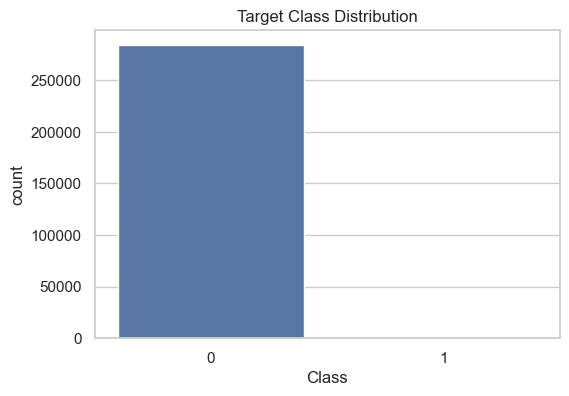

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class")
plt.title("Target Class Distribution")
plt.show()

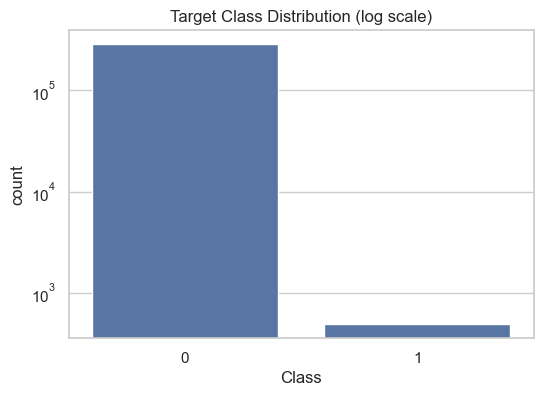

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class")
plt.yscale("log")
plt.title("Target Class Distribution (log scale)")
plt.show()

## 3. Summary statistics and core distributions
`Amount` and `Time` are the only interpretable original features, so they deserve special attention.

In [11]:
df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].head(10)

,mean,std,min,25%,50%,75%,max
Time,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


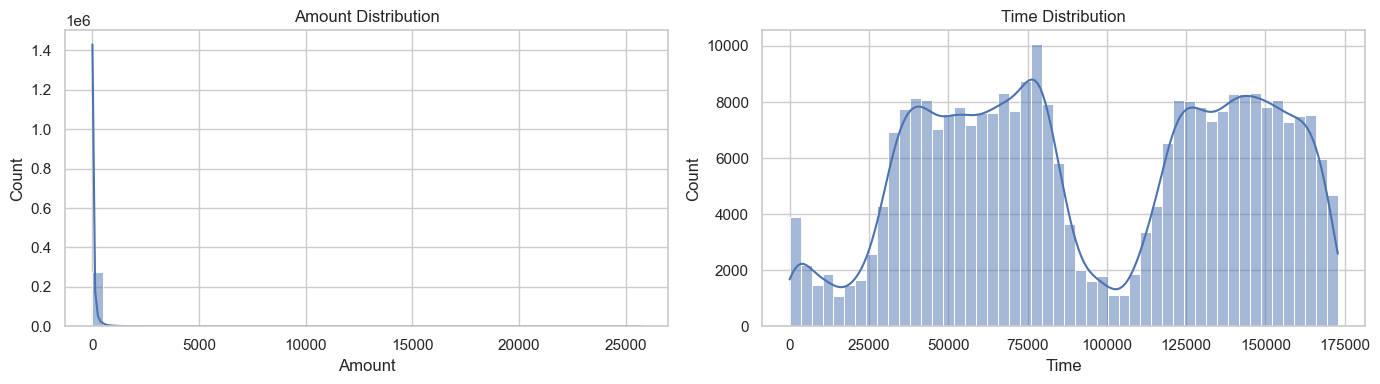

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Amount"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Amount Distribution")
sns.histplot(df["Time"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Time Distribution")
plt.tight_layout()
plt.show()

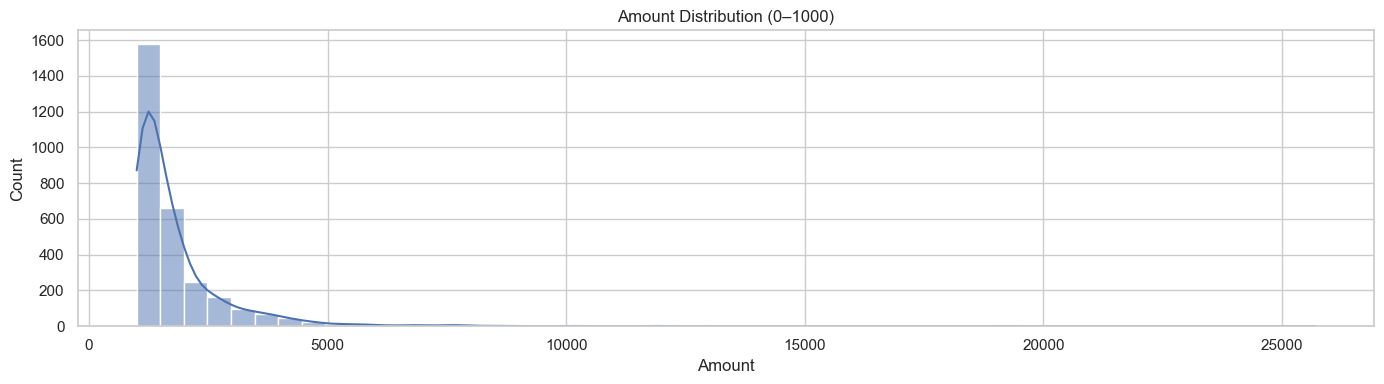

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

sns.histplot(df[df["Amount"] > 1000]["Amount"], bins=50, kde=True, ax=ax)
#ax.set_xlim(0, 1000)  # show only 0–1000
ax.set_title("Amount Distribution (0–1000)")
ax.set_xlabel("Amount")

plt.tight_layout()
plt.show()

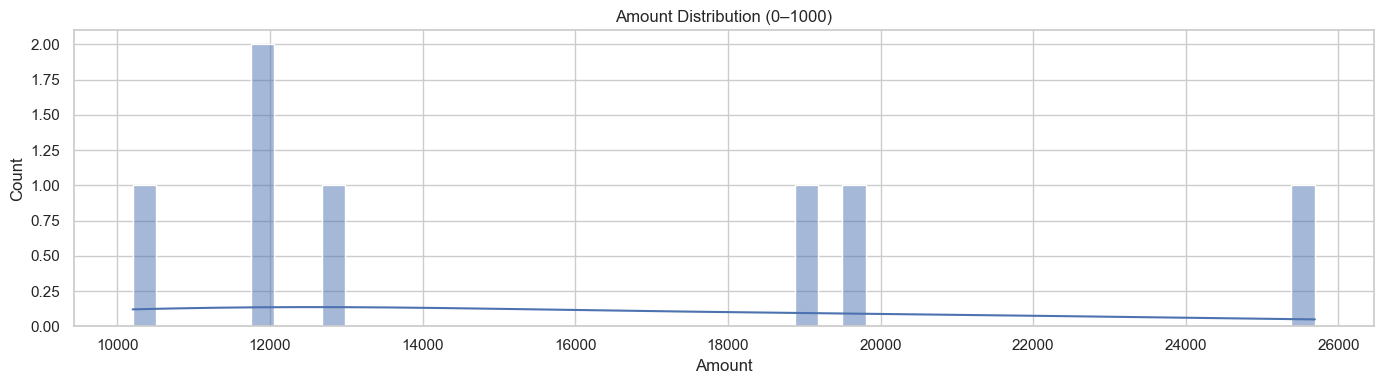

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

sns.histplot(df[df["Amount"] > 10000]["Amount"], bins=50, kde=True, ax=ax)
#ax.set_xlim(0, 1000)  # show only 0–1000
ax.set_title("Amount Distribution (0–1000)")
ax.set_xlabel("Amount")

plt.tight_layout()
plt.show()

## 4. Feature relationships with fraud
We compare a few high-signal variables against the target.

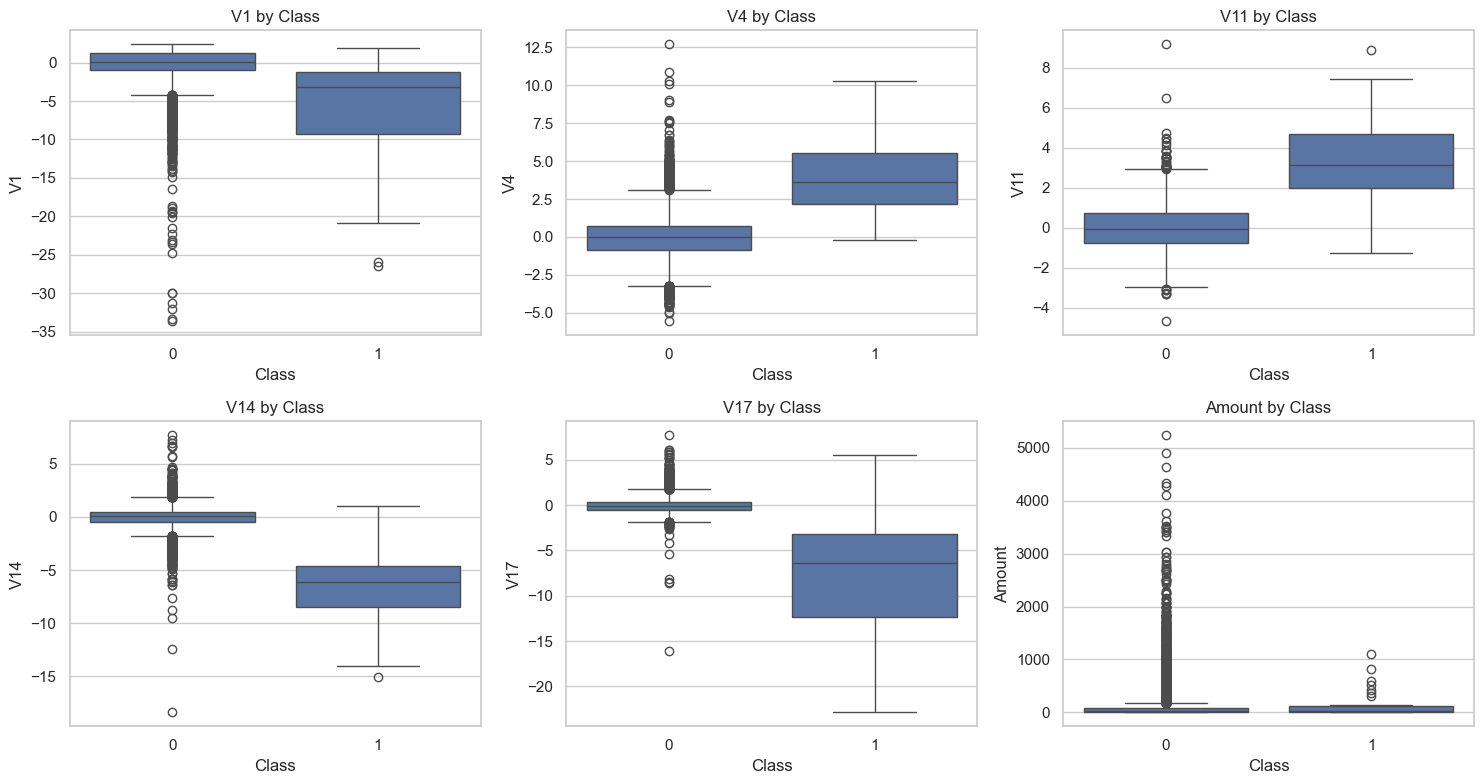

In [15]:
selected_features = ["V1", "V4", "V11", "V14", "V17", "Amount"]
sampled_df = df.sample(min(len(df), 20000), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), selected_features):
    sns.boxplot(data=sampled_df, x="Class", y=col, ax=ax)
    ax.set_title(f"{col} by Class")
plt.tight_layout()
plt.show()

## 5. Correlation analysis
Most variables are PCA components, so correlation is mainly used here for signal screening, not business explanation.

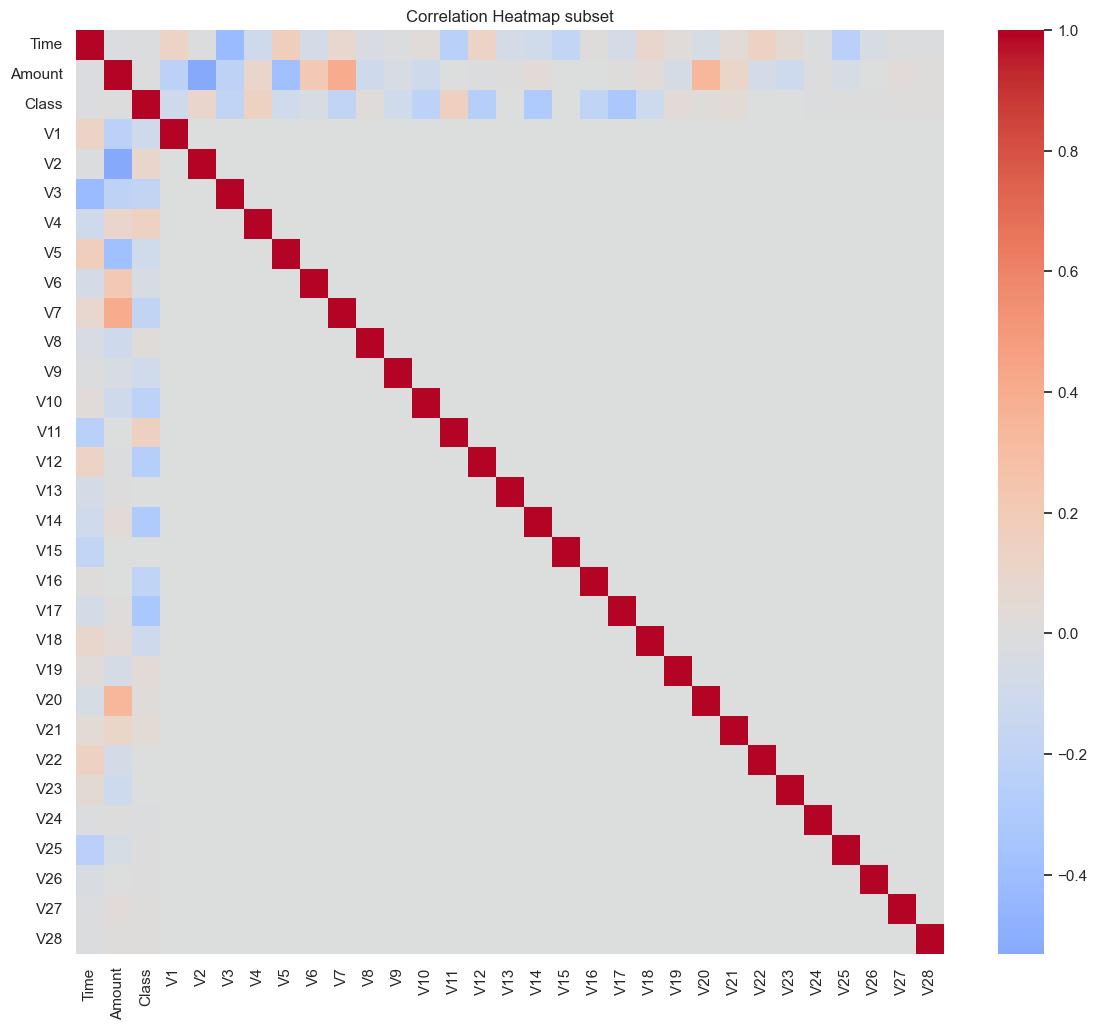

In [16]:
corr_subset = ["Time", "Amount", "Class"] + [f"V{i}" for i in range(1, 29)]
plt.figure(figsize=(14, 12))
sns.heatmap(df[corr_subset].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap subset")
plt.show()

In [17]:
target_corr = df.corr(numeric_only=True)["Class"].drop("Class")
target_corr = target_corr.sort_values(key=lambda s: s.abs(), ascending=False)
target_corr.head(10).to_frame("corr_with_class")

,corr_with_class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


## 6. Outlier checks
Outliers in fraud data are not automatically bad records; they may be the signal.

In [18]:
for col in ["Amount", "Time"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: outliers={outliers}, pct={outliers/len(df)*100:.2f}%")

Amount: outliers=31904, pct=11.20%
Time: outliers=0, pct=0.00%


## 7. Statistical tests
We use robust and classical tests carefully:
- Mann-Whitney U for non-normal class comparisons
- ANOVA as a classical mean-difference reference
- Chi-square only after binning a continuous variable (`Amount`)

In [19]:
test_cols = ["Amount", "V4", "V11", "V14", "V17"]
print("c")
for col in test_cols:
    x = df.loc[df["Class"] == 0, col]
    y = df.loc[df["Class"] == 1, col]
    _, p = mannwhitneyu(x, y, alternative="two-sided")
    print(f"{col}: p_value={p:.6g}")

print("\nANOVA")
for col in test_cols:
    x = df.loc[df["Class"] == 0, col]
    y = df.loc[df["Class"] == 1, col]
    _, p = f_oneway(x, y)
    print(f"{col}: p_value={p:.6g}")

df["AmountBin"] = pd.qcut(df["Amount"].rank(method="first"), q=10, duplicates="drop")
cont_table = pd.crosstab(df["AmountBin"], df["Class"])
chi2, p, dof, _ = chi2_contingency(cont_table)
print(f"\nChi-square on binned Amount: chi2={chi2:.4f}, p_value={p:.6g}, dof={dof}")

c
Amount: p_value=8.57847e-06
V4: p_value=3.6259e-248
V11: p_value=4.91059e-226
V14: p_value=1.47158e-260
V17: p_value=9.21938e-124

ANOVA
Amount: p_value=0.00265122
V4: p_value=0
V11: p_value=0
V14: p_value=0
V17: p_value=0

Chi-square on binned Amount: chi2=443.5153, p_value=6.97714e-90, dof=9


## 8. Initial business insights
1. Fraud is extremely rare, so accuracy will be misleading.
2. Duplicate rows need investigation before modeling because they can distort validation.
3. Some PCA components (`V14`, `V17`, `V12`, `V10`) show strong association with fraud, but they are not directly interpretable.
4. `Amount` has a significant class difference and many outliers, so it may matter for cost-sensitive modeling and threshold tuning.
5. EDA suggests this should be treated as an imbalanced classification problem with strong focus on precision-recall tradeoffs.